# Lecture 2 — Bar Charts 📊: From Basic to Professional

**Dataset:** World Happiness Report 2023. Download from: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023 

**Source of figures:** > *Knaflic, C. N. (2015). *Storytelling with data*. Wiley.*


---
## Warm-up (10 mins): 

- Pull today's lecture materials from the course material repo: https://github.com/dina-deifallah/data-viz-class-material.git

- Open the notebook named lecture02_notes

- create your course work Github repo as outlined in lecture01 notes on Teams. Make sure it is public!

- Add your name, mart. number, group and repo link in this excel sheet: https://bitsiserlohn-my.sharepoint.com/:x:/g/personal/dina_deifallah_ue-germany_de/IQBpBkbXNZo-TLlfrmxcpu7rAbPuoGRelMxl-Zso2AUuzI8?e=Z5Bwrj&nav=MTVfezAwMDAwMDAwLTAwMDEtMDAwMC0wMDAwLTAwMDAwMDAwMDAwMH0

---
## Design Principle - Part I: Context Before Charts




### Exploratory vs Explanatory Analysis

> 🗣 *'Before we write a single line of code, one distinction defines this entire course.'*

**[ FIGURE 0.2 — p.20 ]**

*Ticket volume: raw data dump — exploratory analysis*

> 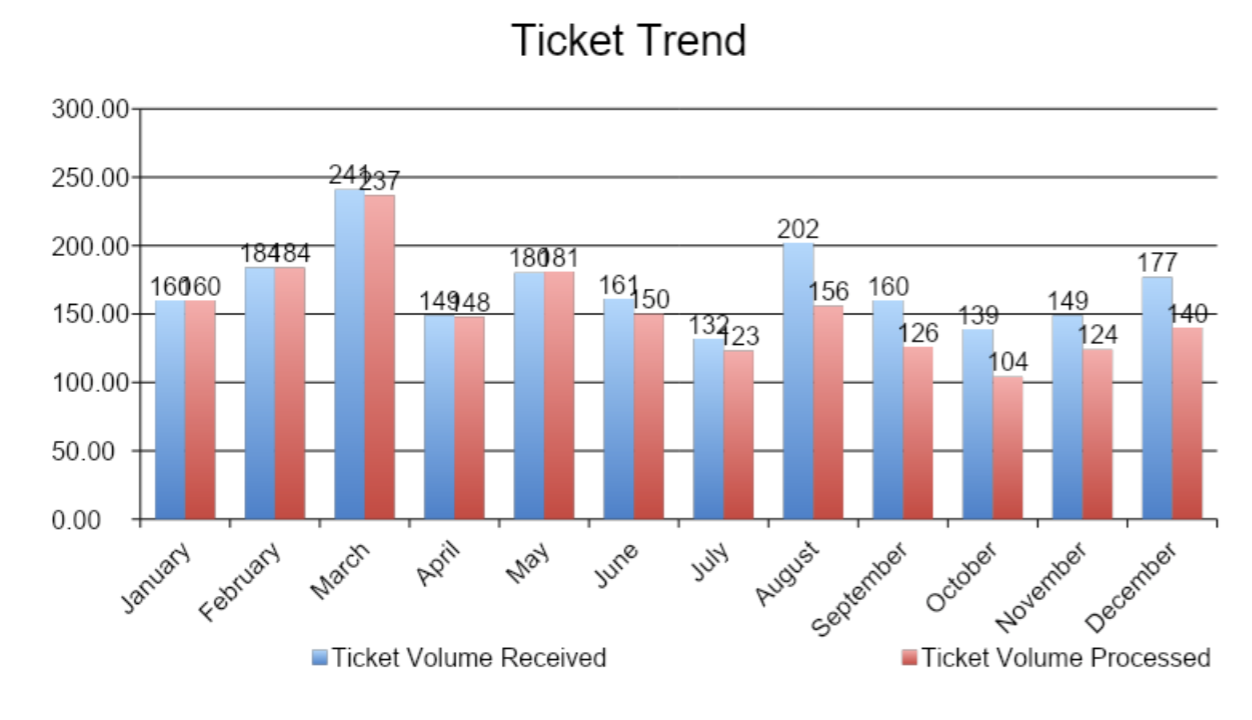 


### So how can we make it explanatory? 🧐

**[ FIGURE 0.3 — p.20 ]**

*Same data: storytelling makeover — explanatory analysis*

> 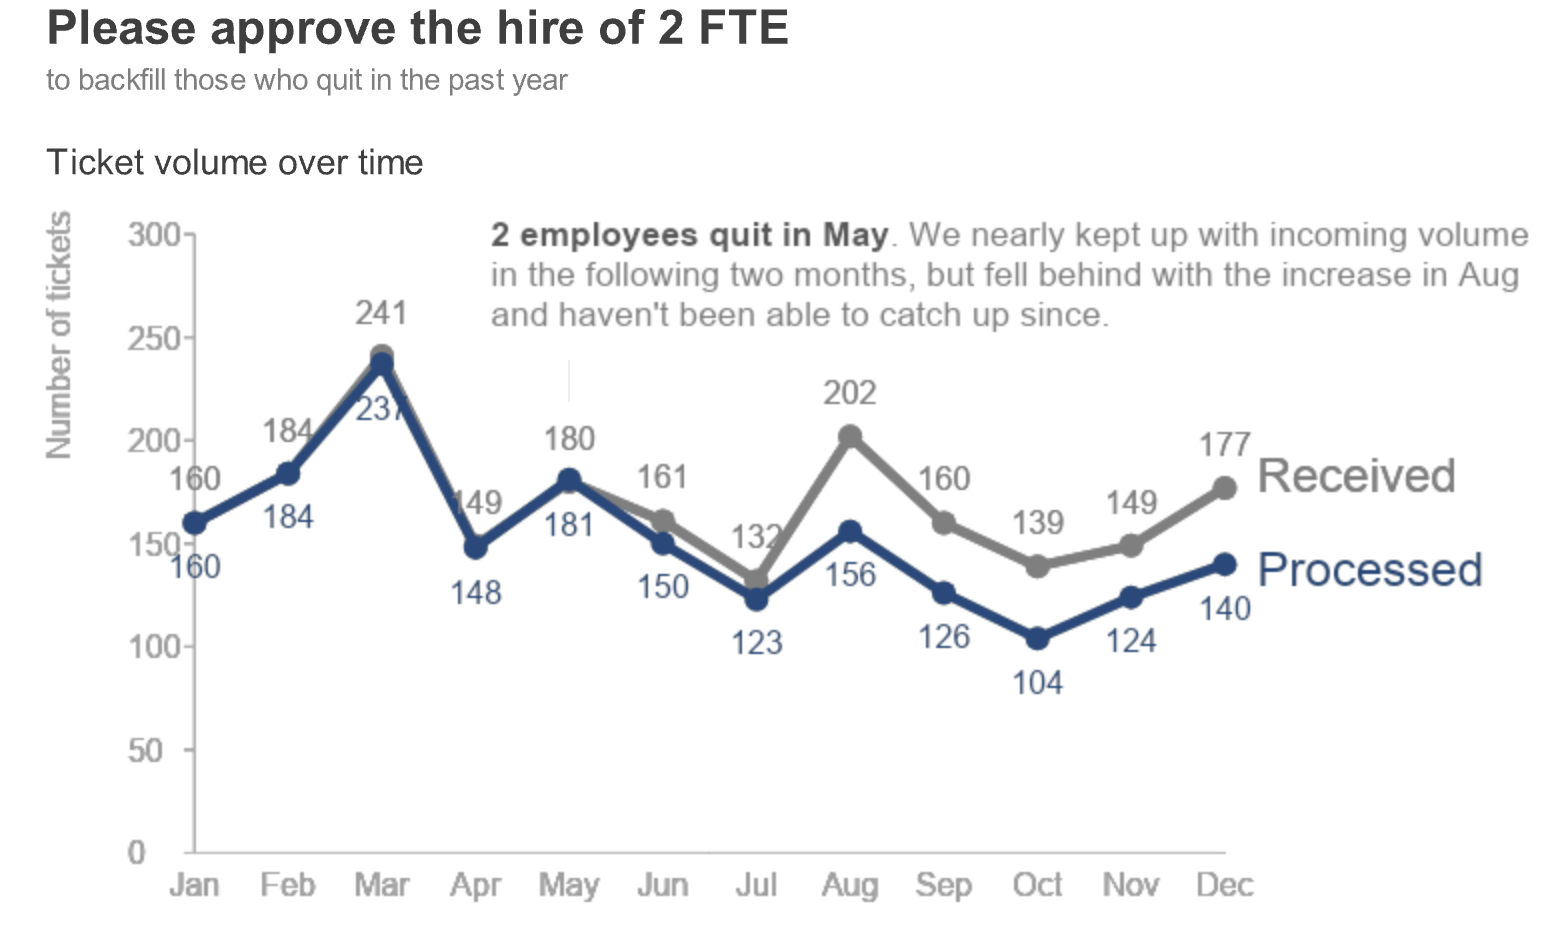  


**What specifically changed between these two charts?**

| Exploratory | Explanatory |
|---|---|
| For yourself | For your audience |
| Rough, fast, Seaborn defaults | Polished, purposeful |
| 100 oysters | The 2 pearls |

### ❓ Three Questions Before Any Chart ❓

**[ FIGURE 1.1 — p.24 ]**

*Communication mechanism continuum: live presentation ↔ written document*

> 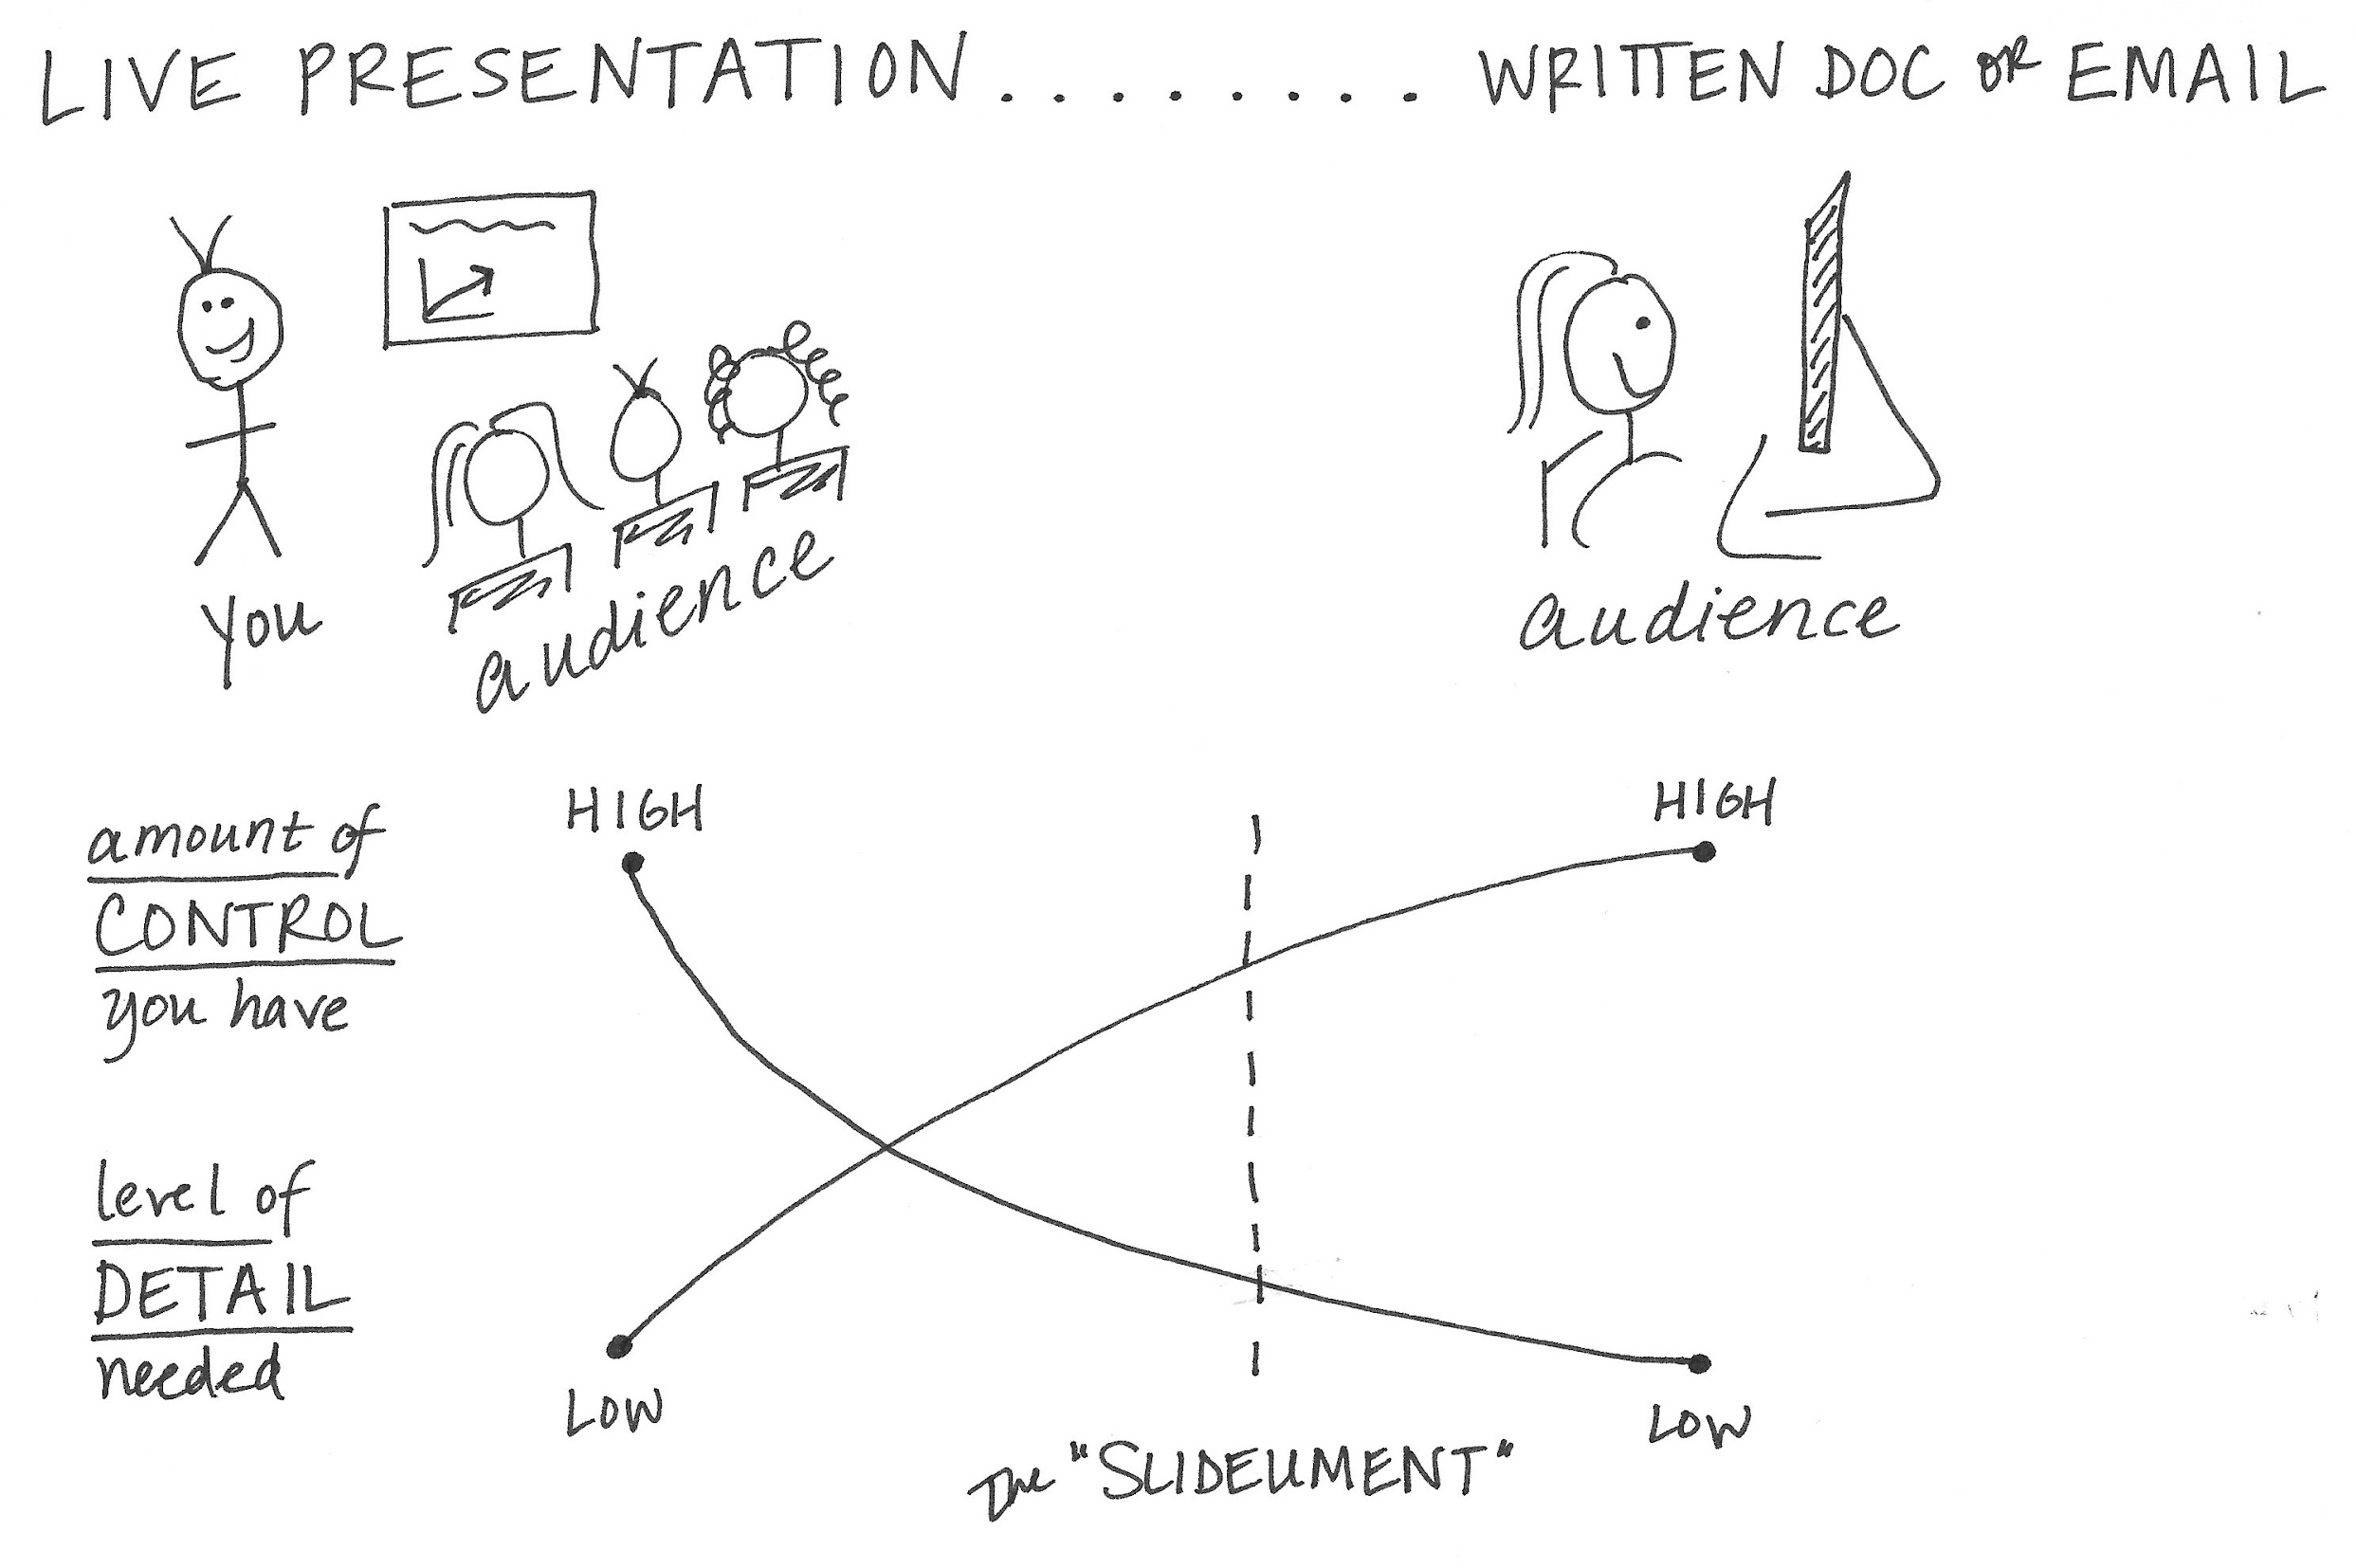 


#### 💡 Before coding, answer 3 important questions:

**1. WHO is your audience?**  
A specific person or role — not 'stakeholders'. The more specific, the better.

**2. WHAT do you need them to know or do?**  
One action, one sentence. If you can't state it, you don't know what the chart is for.

**3. HOW will they consume it?**  
Live presentation vs. standalone email changes how much annotation and context you need.

#### 💡 Title your figure with a single sentence that articulates your point of view, conveys what's at stake, and uses a verb:

> ❌ *'Happiness Scores by Country'*  
> ✅ *'Nordic countries lead global happiness by a wide margin — and the gap is widening'*

---
## Design Principles- Part II: Bar Chart Principles


### Why Bar Charts?

- Bar charts are sometimes avoided because they are common. That is a mistake. Use them **because** they are common — your audience spends zero effort reading them, and all their attention on your message.

- ‼️ The eye compares **end points** of bars — ranking and differences are immediately clear ‼️

### Rule 1 💡: Zero Baseline — Always

**[ FIGURE 2.12, 2.13 — p.66, 67 ]**

> 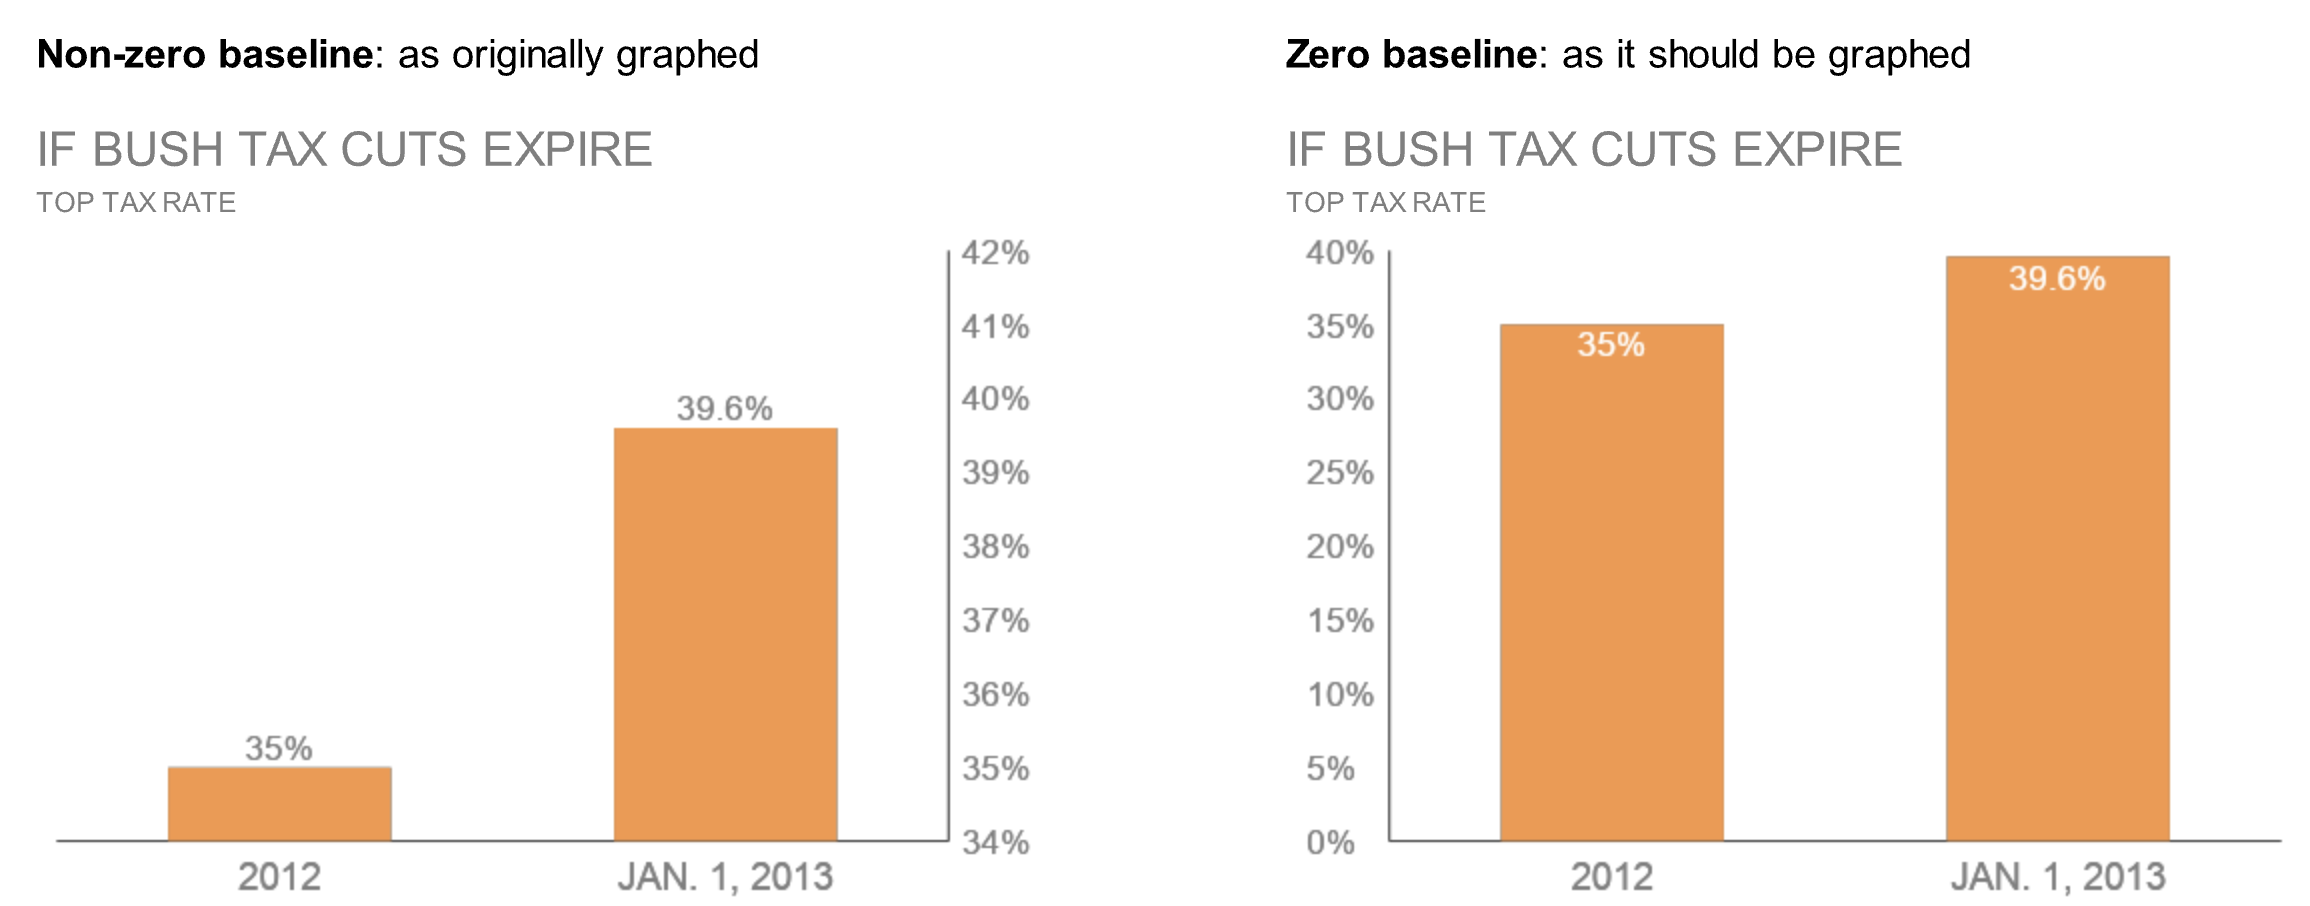 

*Fox News bar chart: y-axis starts at 34, not 0 — a 13% increase looks like 460%*

*Corrected version with zero baseline: the real difference is modest*

*Starting the axis at 34 instead of 0 inflated the visual difference by more than 35×. The zero baseline rule has no exceptions for bar charts.*

### Rule 2 💡: Sort Meaningfully

If there is no natural order, sort by value. Your audience reads from the top.

| Has natural order → keep it | No natural order → sort by value |
|---|---|
| Age groups, time periods | Countries, departments, product names |


### Rule 3 💡: Horizontal for Long Labels

**[ FIGURE 2.18 — p.73 ]**

*Horizontal bar chart: the label is read before the value — natural reading direction*

> 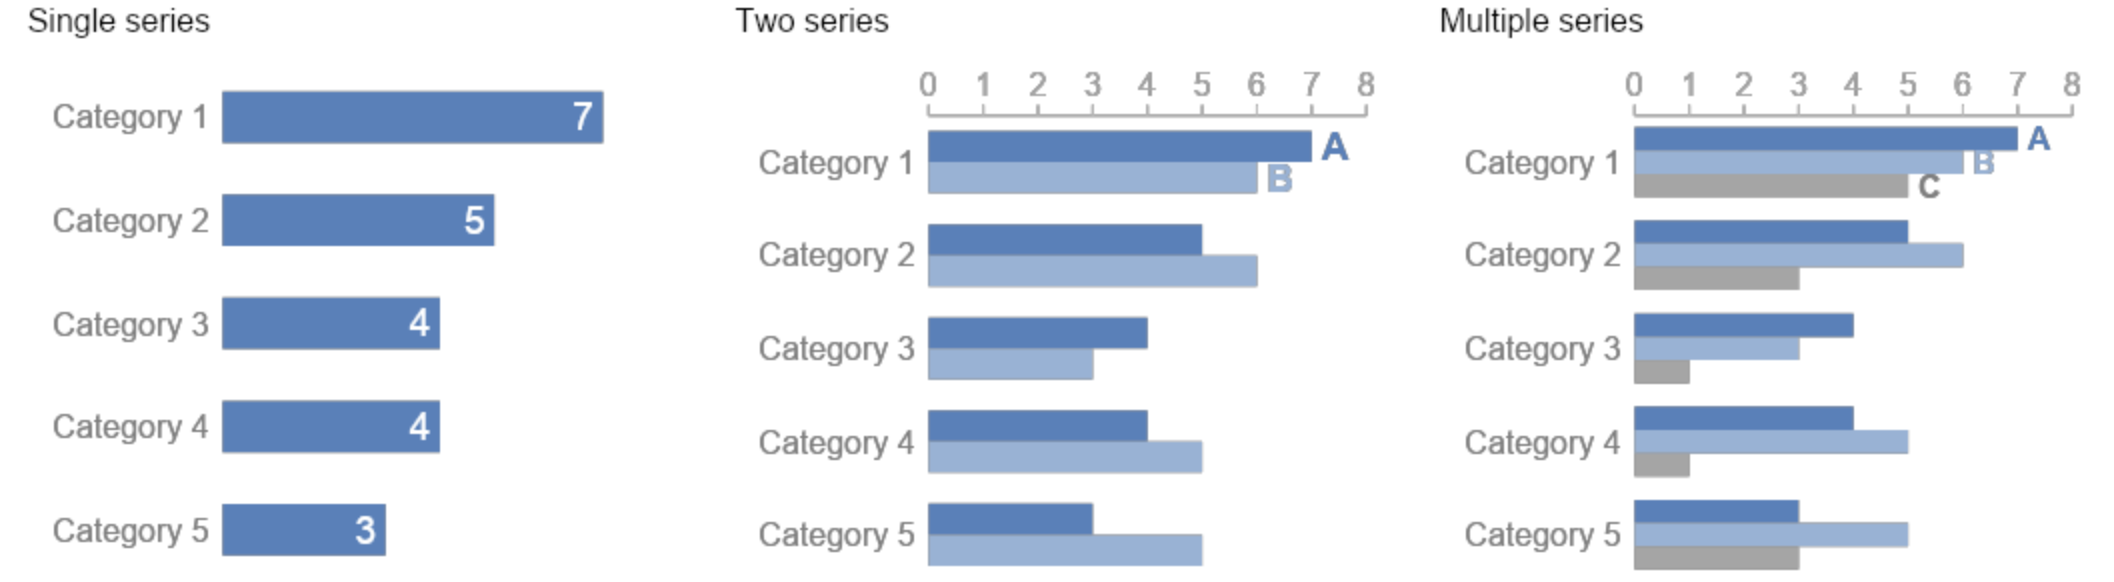 


- With horizontal bars, the audience reads the category name first — then the bar. By the time they see the data, they already know what they are looking at

- **Rule of thumb:** if category names are longer than ~8 characters, use horizontal

### Rule 4 💡: Bar Width — The Goldilocks Rule

*Bar width: not too thin / **just right** / not too thick*

Bars should be **wider than the gaps between them**

### Why Not Pie Charts?

**[ FIGURE 2.21 — p.78 ]**

*Pie chart: Supplier B looks largest — but is actually smaller than Supplier A*

> 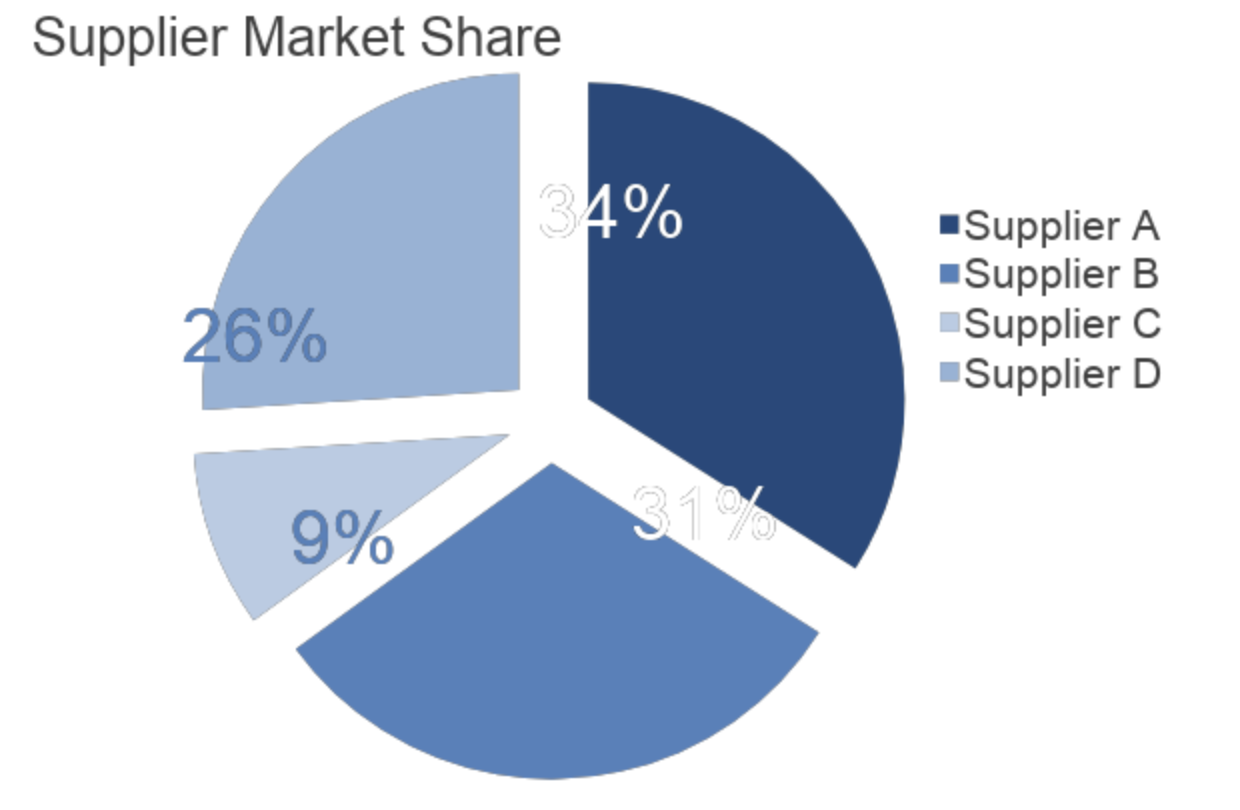 


**[ FIGURE 2.23 — p.80 ]**

*Horizontal bar makeover: ranking is instantly clear*

>  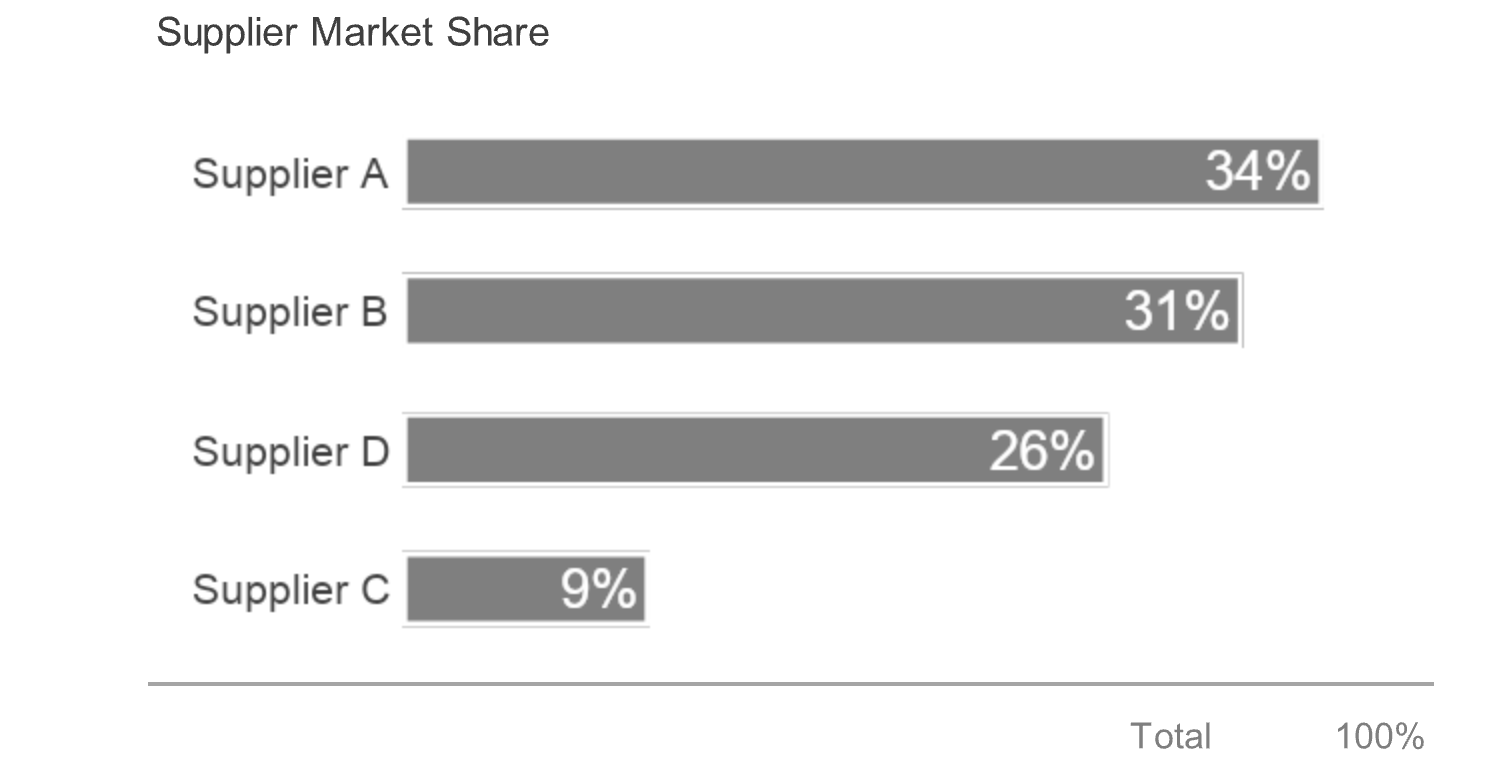 

- Pie charts ask the audience to judge angles. Humans are very poor at this. The 3D perspective makes it worse — it distorts areas so nearer slices look larger*

- A sorted horizontal bar chart is almost always a better alternative

- **The one exception:** two slices only, and the part-to-whole relationship is the entire story


### Rule 5 💡: Stacked Bars to Be Used With Care

**[ FIGURE 2.16 — p.71 ]**

*Stacked bars: bottom segment (blue) is easy to compare; any segment above it is hard*

> 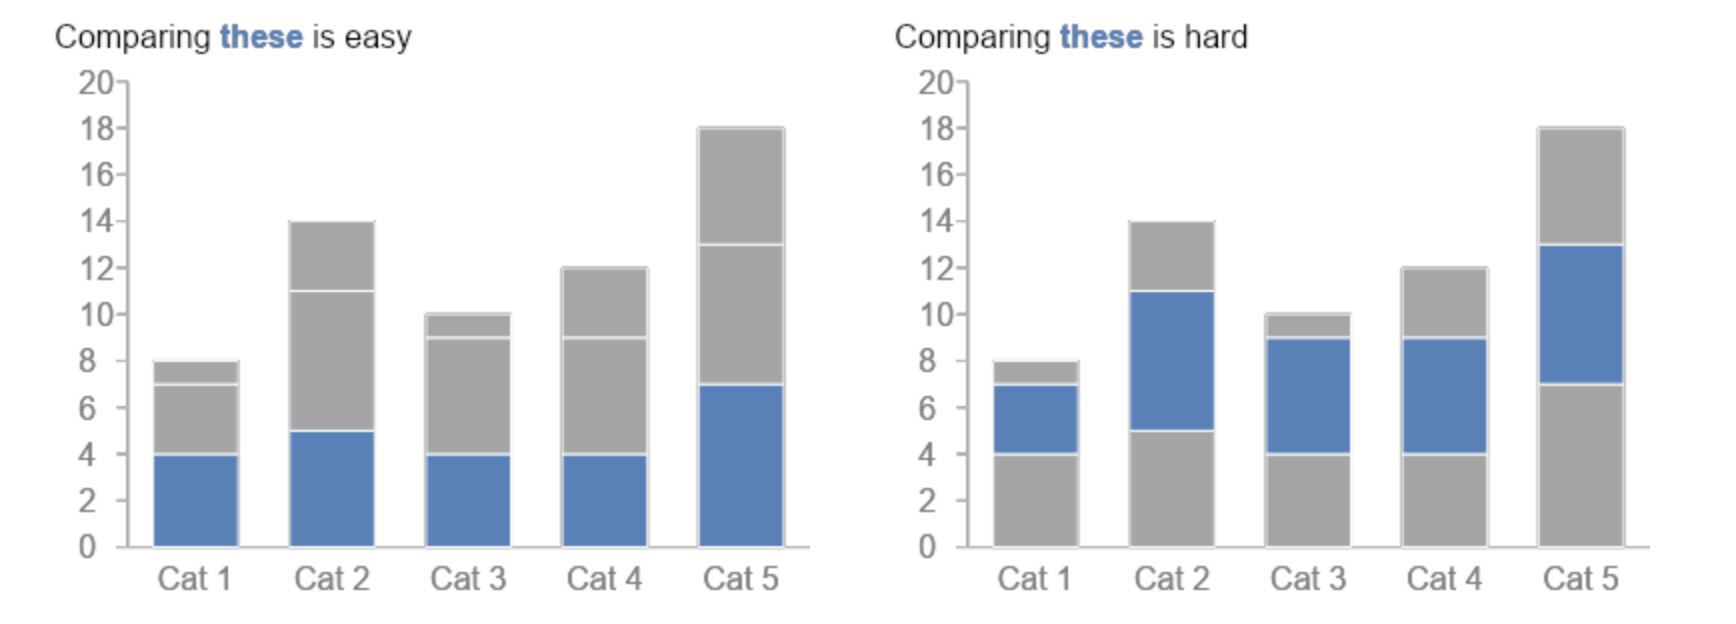 

- ‼️ Only the bottom segment has a zero baseline. Every segment above it floats — the eye cannot reliably compare floating bars across groups ‼️

**Use stacked bars only when:**
- You care about both the **total** and the **composition**
- You have **2–3 segments maximum**
- The **most important segment is on the bottom**


---
## Let's Code Some Examples 💻 

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/world_happiness_2023.csv')
df.columns = ['Country','Region','Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']
print(f"{len(df)} countries loaded")
print(df.head())


### Step 1 — The Seaborn default


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = df.nlargest(10, 'Score')
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10, x='Country', y='Score', ax=ax)
ax.set_title('Top 10 Happiest Countries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### which of the 4 rules are we breaking?


- Rule 2: bars not sorted by value
- Rule 3: vertical bars with long labels — rotated text is hard to read
- Title: topic, not insight


### Step 2 — Plotly Express w/ some Customizations


In [ ]:
fig = px.bar(
    top10.sort_values('Score'),       # Rule 2: sort
    x='Score', y='Country',
    orientation='h',                  # Rule 3: horizontal
    title='Top 10 Happiest Countries 2023',
    height=500
      
)
fig.show()


### Step 3 — Apply all 4 rules


In [ ]:
fig = px.bar(
    df.nlargest(15, 'Score').sort_values('Score'),
    x='Score', y='Country',
    orientation='h',
    title='Nordic countries occupy 5 of the top 7 happiest nations in 2023',
    labels={'Score': 'Happiness Score (0–10)', 'Country': ''},
    color_discrete_sequence=['#2E75B6']
)
fig.update_layout(
    xaxis=dict(range=[0, 8.5]),      # Rule 1: make sure to have zero baseline — always
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    xaxis_gridcolor='#EEEEEE',
    yaxis_gridcolor='white',
    showlegend=False,
    margin=dict(l=10, r=30, t=50, b=40),
    height=550
)

fig.update_traces(marker_line_width=0)
fig.show()


### Step 4 — Colour as emphasis (preview of Lecture 4)


In [ ]:
# Grey everything, highlight one group — viewer's eye goes straight to colour

top15 = df.nlargest(15, 'Score').sort_values('Score')

# Add a highlight column so px can map colours declaratively
top15 = top15.copy()
top15['highlight'] = top15['Region'].apply(
    lambda r: 'Western Europe' if r == 'Western Europe' else 'Other'
)

# --- px as the starting point ---
fig = px.bar(
    top15,
    x='Score', y='Country',
    orientation='h',
    color='highlight',
    color_discrete_map={
        'Western Europe': '#2E75B6',  # blue — stands out
        'Other':          '#D0D0D0'   # grey — recede into background
    },
    title='Western European nations dominate global happiness rankings',
    labels={'Score': 'Score (0-10)', 'Country': '', 'highlight': ''},
    height=550
)

# --- customise via update_*
fig.update_traces(marker_line_width=0)

fig.update_layout(
    xaxis=dict(range=[0, 8.5], gridcolor='#EEEEEE'),
    yaxis=dict(gridcolor='white'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    margin=dict(l=10, r=30, t=50, b=40),
    showlegend=False
)

# adding a text box annotation for clarification of color usage
fig.add_annotation(
    x=7.9, y='United States',
    text='Western Europe in blue',
    showarrow=False,
    font=dict(color='#2E75B6', size=11),
    bgcolor='white', bordercolor='#2E75B6', borderwidth=1, borderpad=4
)

fig.show()

### Step 5 — Stacked bar: composition story


In [ ]:
sub = df[df['Region'].isin(['Western Europe','Sub-Saharan Africa',
                             'East Asia','Latin America and Caribbean','South Asia'])]
region_stack = (sub.groupby('Region')[['GDP','Social_Support','Life_Expectancy','Freedom']]
                .mean().reset_index())
region_stack['total'] = region_stack[['GDP','Social_Support','Life_Expectancy','Freedom']].sum(axis=1)
region_stack = region_stack.sort_values('total')

fig = px.bar(
    region_stack.melt(id_vars='Region',
                      value_vars=['GDP','Social_Support','Life_Expectancy','Freedom']),
    y='Region', x='value', color='variable',
    orientation='h', barmode='stack',
    title='Western Europe leads on all four sub-factors — Sub-Saharan Africa trails on every one',
    labels={'value': 'Contribution Score', 'variable': 'Factor', 'Region': ''},
    color_discrete_sequence=['#2E75B6','#70AD47','#FFC000','#E63946']
)
fig.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    xaxis=dict(gridcolor='#EEEEEE'),
    legend=dict(orientation='h', y=1.08),
    margin=dict(l=10, r=30, t=65, b=40)
)
fig.update_traces(marker_line_width=0)
fig.show()

# Which sub-factor is easiest to compare across regions? Hardest?
# GDP (bottom, zero baseline) = easy. Freedom (top, floating) = hard


---
## Transition to Exercise (~2 min)

> *Exercise is in `lecture02_exercise.ipynb`. One main task, one extension. Push to `week02/` in your repo before you leave.*

**The 4 rules — these will be checked:**
1. Zero baseline on all bar charts
2. Sort by value if no natural order
3. Horizontal for long labels
4. Insight title, not topic title
